# SOM as a Nonlinear Projection Method

Kohonen argues that the SOM belongs to the family of **nonlinear projection methods**, alongside multidimensional scaling (MDS) and the Sammon mapping. This notebook tests that claim quantitatively by comparing DBGSOM against sklearn manifold methods on the MNIST dataset.

**Methods compared:** DBGSOM · Isomap · t-SNE · UMAP · **SOM→UMAP**  
**Metrics:** Trustworthiness · Continuity · Runtime

> **SOM→UMAP:** The trained SOM's `transform()` method encodes each sample as a sparse mixture of prototype weights. UMAP then projects these sparse codes to 2D — combining the SOM's topology-preserving quantization with UMAP's local structure preservation.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.manifold import trustworthiness
from umap import UMAP

from dbgsom.SomVQ import SomVQ

## Dataset

MNIST contains 28×28 greyscale images of handwritten digits (0–9), represented as 784-dimensional vectors. The full dataset has 70 000 samples; a stratified subsample of 10 000 is used here so that Isomap (O(n²)) remains tractable. Pixel values are normalised to [0, 1].


In [8]:
from sklearn.model_selection import train_test_split

try:
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X_full, y_full = mnist.data / 255.0, mnist.target.astype(int)
    # Stratified subsample — Isomap is O(n²); 10 000 keeps runtime tractable
    X, _, y, _ = train_test_split(
        X_full, y_full, train_size=5000, stratify=y_full, random_state=42
    )
    print(f"MNIST  — Shape: {X.shape}  |  Classes: {np.unique(y)}")
except Exception as e:
    from sklearn.datasets import load_digits

    print(f"OpenML unreachable ({type(e).__name__}), falling back to Digits.")
    X, y = load_digits(return_X_y=True)
    print(f"Digits — Shape: {X.shape}  |  Classes: {np.unique(y)}")

MNIST  — Shape: (5000, 784)  |  Classes: [0 1 2 3 4 5 6 7 8 9]


## Train All Methods


In [15]:
# --- DBGSOM ---
from sklearn.manifold import TSNE, Isomap

t0 = time.perf_counter()
som = SomVQ(
    random_state=42,
    n_iter=500,
    verbose=False,
    lambda_=15.8,
    pointer_search="all",
)
som.fit(X)
t_som = time.perf_counter() - t0

bmu_indices = som.predict(X)
som_coords = np.array([som.neurons_[i] for i in bmu_indices], dtype=float)

# --- Isomap ---
t0 = time.perf_counter()
isomap_coords = Isomap(n_components=2, n_neighbors=10).fit_transform(X)
t_isomap = time.perf_counter() - t0

# --- UMAP ---
t0 = time.perf_counter()
umap = UMAP(n_components=2, n_neighbors=5)
umap_coords = umap.fit_transform(X)
t_umap = time.perf_counter() - t0

# --- t-SNE ---
t0 = time.perf_counter()
tsne_coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)
t_tsne = time.perf_counter() - t0

embeddings = {
    "DBGSOM": som_coords,
    "Isomap": isomap_coords,
    "t-SNE": tsne_coords,
    "UMAP": umap_coords,
}
runtimes = {
    "DBGSOM": t_som,
    "Isomap": t_isomap,
    "t-SNE": t_tsne,
    "UMAP": t_umap,
}

print(f"{'Method':<12} {'Runtime (s)':>12}")
for name, t in runtimes.items():
    extra = f"  ({som.som_.number_of_nodes()} neurons)" if name == "DBGSOM" else ""
    print(f"{name:<12} {t:>12.3f}{extra}")

Method        Runtime (s)
DBGSOM              1.206  (118 neurons)
Isomap              5.094
t-SNE              10.969
UMAP                0.710


## Trustworthiness & Continuity

**Trustworthiness** asks: are the k nearest neighbours in the embedding also close in the original space? (Precision)  
**Continuity** asks: are the k nearest neighbours in the original space also close in the embedding? (Recall)

Both metrics are from Venna & Kaski (2001). Continuity is computed by swapping the roles of `X` and `X_emb` in the trustworthiness formula.


In [10]:
def continuity(X, X_emb, n_neighbors):
    return trustworthiness(X_emb, X, n_neighbors=n_neighbors)


k_values = [5, 10, 20]
rows = []
for name, emb in embeddings.items():
    row = {"Method": name}
    for k in k_values:
        row[f"T (k={k})"] = round(trustworthiness(X, emb, n_neighbors=k), 4)
        row[f"C (k={k})"] = round(continuity(X, emb, n_neighbors=k), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
print(df.to_string())
df

        T (k=5)  C (k=5)  T (k=10)  C (k=10)  T (k=20)  C (k=20)
Method                                                          
DBGSOM   0.9490   0.9286    0.9507    0.9198    0.9515    0.9096
Isomap   0.7663   0.9567    0.7679    0.9516    0.7677    0.9385
t-SNE    0.9897   0.9761    0.9817    0.9667    0.9704    0.9552
UMAP     0.9685   0.9752    0.9640    0.9628    0.9561    0.9487


,T (k=5),C (k=5),T (k=10),C (k=10),T (k=20),C (k=20)
Method,,,,,,
DBGSOM,0.9490,0.9286,0.9507,0.9198,0.9515,0.9096
Isomap,0.7663,0.9567,0.7679,0.9516,0.7677,0.9385
t-SNE,0.9897,0.9761,0.9817,0.9667,0.9704,0.9552
UMAP,0.9685,0.9752,0.9640,0.9628,0.9561,0.9487


## Topographic Function (Villmann 1997)

The **topographic function** Φ(k) quantifies topology preservation at every neighbourhood scale k, in both directions:

- **k > 0 — folds:** fraction of input-graph-adjacent pairs that are >k hops apart in the embedding graph
- **k < 0 — tears:** fraction of embedding-graph-adjacent pairs that are >|k| hops apart in the input graph
- **k = 0:** Φ(−1) + Φ(+1) — combined bidirectional error; Φ(0) = 0 iff perfectly topology-preserving

The k = ±1 case is the bidirectional generalisation of the standard topographic error:
`Φ(+1)` ≈ 1 − Continuity,  `Φ(−1)` ≈ 1 − Trustworthiness.

**Graph construction per method:**

| Method | Input graph D_M | Embedding graph A |
|--------|----------------|-------------------|
| UMAP | `umap.graph_` (precomputed fuzzy k-NN, binarised) | k-NN on 2D coords |
| t-SNE, Isomap | k-NN on X (k = 5) | k-NN on 2D coords |
| DBGSOM | competitive Hebbian (BMU1–BMU2 edges) | SOM lattice graph |

UMAP's `graph_` is its direct optimisation target — Φ(0) = 0 is literally UMAP's goal.

*Reference: Villmann T., Der R., Herrmann M., Martinetz T.M. (1997). Topology Preservation in Self-Organizing Feature Maps. IEEE TNN 8(2).*

In [18]:
from scipy.sparse import triu
from sklearn.neighbors import kneighbors_graph


def to_binary_adj(adj):
    """Weighted sparse matrix → unweighted symmetric binary adjacency."""
    a = adj + adj.T
    a = a.tocsr()
    a.data[:] = 1.0
    a.eliminate_zeros()
    return a


def build_knn_adj(coords, n_neighbors):
    """Symmetric unweighted k-NN adjacency from coordinate matrix."""
    g = kneighbors_graph(coords, n_neighbors, mode="connectivity", include_self=False)
    return to_binary_adj(g)


def topographic_te_bidir(adj_input, adj_embed):
    """Bidirectional topographic error (k = ±1) via sparse operations.

    Memory-efficient: O(E), no dense N×N matrix.

    Returns
    -------
    dict with te_folds (k=+1), te_tears (k=−1), te_combined (k=0).

    """
    ai = triu(adj_input, k=1)  # upper triangle, unordered pairs
    ae = triu(adj_embed, k=1)

    n_in = ai.nnz
    n_emb = ae.nnz
    n_both = triu(ai.multiply(ae), k=1).nnz  # intersection

    n = adj_input.shape[0]
    norm = n * max(n - 6, 1)

    folds = (n_in - n_both) / norm  # input-adjacent but NOT embed-adjacent
    tears = (n_emb - n_both) / norm  # embed-adjacent  but NOT input-adjacent
    return {
        "te_folds": folds,
        "te_tears": tears,
        "te_combined": folds + tears,
    }

In [19]:
N_NBR = 5  # must match UMAP's n_neighbors

# UMAP: use precomputed graph_ as input graph (binarise fuzzy weights)
adj_umap_in = to_binary_adj(umap.graph_)
adj_umap_emb = build_knn_adj(umap_coords, N_NBR)

# Shared input graph for t-SNE and Isomap
adj_X = build_knn_adj(X, N_NBR)

te_umap = topographic_te_bidir(adj_umap_in, adj_umap_emb)
te_tsne = topographic_te_bidir(adj_X, build_knn_adj(tsne_coords, N_NBR))
te_isomap = topographic_te_bidir(adj_X, build_knn_adj(isomap_coords, N_NBR))

# DBGSOM: principled API — SOM lattice graph + competitive Hebbian Delaunay
tf_som = som.topographic_function(X)  # shape (2, K): row0=phi, row1=k_norm

# Reconstruct bidir TE from SOM topographic function at k=±1
som_k0_idx = tf_som.shape[1] // 2  # index where k_norm ≈ 0
te_som = {
    "te_folds": tf_som[0, som_k0_idx + 1],
    "te_tears": tf_som[0, som_k0_idx - 1],
    "te_combined": tf_som[0, som_k0_idx],
}

results = {
    "UMAP": te_umap,
    "t-SNE": te_tsne,
    "Isomap": te_isomap,
    "DBGSOM": te_som,
}

rows = [
    {
        "Method": name,
        "Φ(+1) folds": f"{r['te_folds']:.5f}",
        "Φ(−1) tears": f"{r['te_tears']:.5f}",
        "Φ(0) combined": f"{r['te_combined']:.5f}",
    }
    for name, r in results.items()
]
df_tf = pd.DataFrame(rows).set_index("Method")
print(df_tf.to_string())

       Φ(+1) folds Φ(−1) tears Φ(0) combined
Method                                      
UMAP       0.00036     0.00038       0.00074
t-SNE      0.00042     0.00028       0.00070
Isomap     0.00071     0.00058       0.00129
DBGSOM     0.06507     0.00121       0.06628


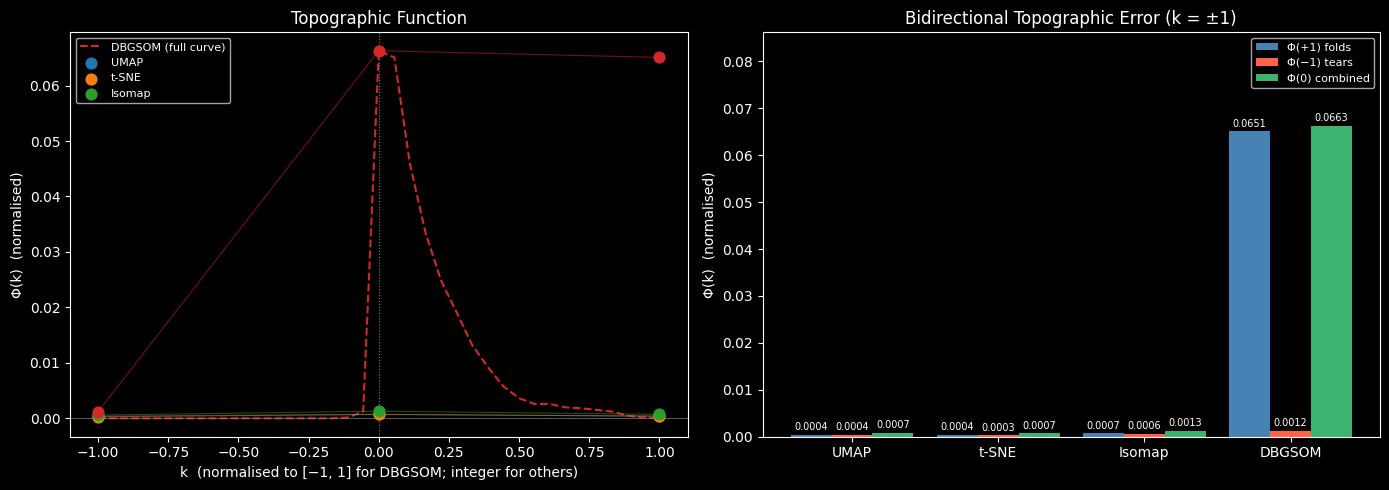

,Φ(+1) folds,Φ(−1) tears,Φ(0) combined
Method,,,
UMAP,0.00036,0.00038,0.00074
t-SNE,0.00042,0.00028,0.00070
Isomap,0.00071,0.00058,0.00129
DBGSOM,0.06507,0.00121,0.06628


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab10", 4)
method_colors = dict(zip(["UMAP", "t-SNE", "Isomap", "DBGSOM"], palette))

# --- Panel 1: SOM Φ(k) curve + k=±1 markers for all methods ---
ax = axes[0]
# SOM full curve
ax.plot(
    tf_som[1],
    tf_som[0],
    color=method_colors["DBGSOM"],
    lw=1.5,
    ls="--",
    label="DBGSOM (full curve)",
)
# k=±1 markers for all methods
for name, r in results.items():
    color = method_colors[name]
    ax.scatter(
        [-1, 0, 1],
        [r["te_tears"], r["te_combined"], r["te_folds"]],
        color=color,
        s=60,
        zorder=5,
        label=name if name != "DBGSOM" else None,
    )
    ax.plot(
        [-1, 0, 1],
        [r["te_tears"], r["te_combined"], r["te_folds"]],
        color=color,
        lw=0.8,
        alpha=0.5,
    )

ax.axvline(0, color="gray", lw=0.8, ls=":")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("k  (normalised to [−1, 1] for DBGSOM; integer for others)")
ax.set_ylabel("Φ(k)  (normalised)")
ax.set_title("Topographic Function")
ax.legend(fontsize=8)

# --- Panel 2: Grouped bar chart ---
ax2 = axes[1]
methods = list(results.keys())
x = np.arange(len(methods))
w = 0.28

bars_folds = [results[m]["te_folds"] for m in methods]
bars_tears = [results[m]["te_tears"] for m in methods]
bars_comb = [results[m]["te_combined"] for m in methods]

b1 = ax2.bar(x - w, bars_folds, w, label="Φ(+1) folds", color="steelblue")
b2 = ax2.bar(x, bars_tears, w, label="Φ(−1) tears", color="tomato")
b3 = ax2.bar(x + w, bars_comb, w, label="Φ(0) combined", color="mediumseagreen")

ax2.bar_label(b1, fmt="%.4f", fontsize=7, padding=2)
ax2.bar_label(b2, fmt="%.4f", fontsize=7, padding=2)
ax2.bar_label(b3, fmt="%.4f", fontsize=7, padding=2)
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.set_ylabel("Φ(k)  (normalised)")
ax2.set_title("Bidirectional Topographic Error (k = ±1)")
ax2.legend(fontsize=8)
ax2.set_ylim(0, max(bars_comb) * 1.3)

plt.tight_layout()
plt.show()

df_tf

## 2D Scatter Plots

Each point is coloured by its true digit label. The SOM plot uses grid coordinates; overlapping points (multiple samples mapped to the same BMU) are expected.


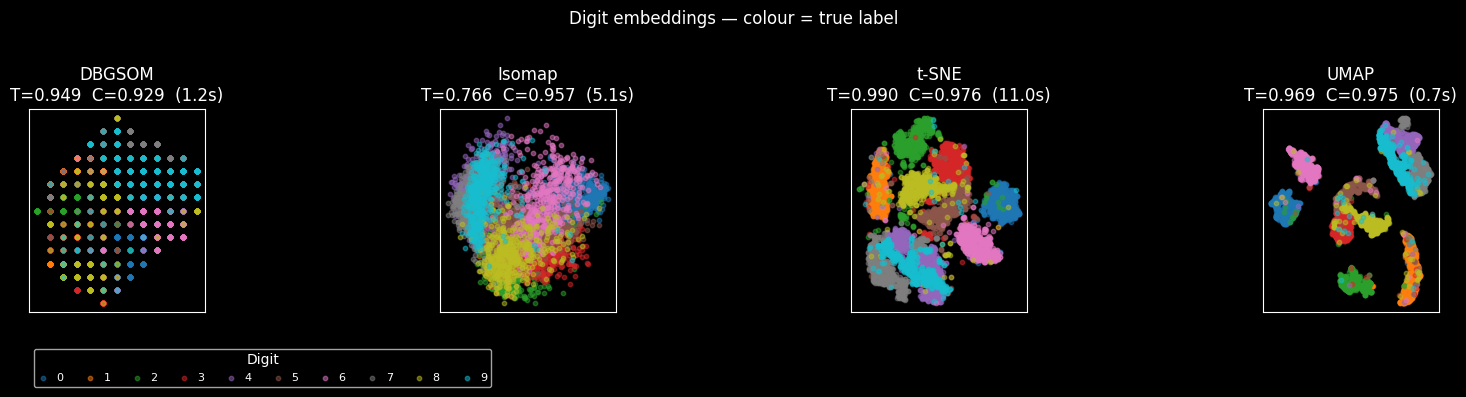

In [21]:
palette = sns.color_palette("tab10", n_colors=10)

n_methods = len(embeddings)
fig, axes = plt.subplots(1, n_methods, figsize=(3.6 * n_methods, 4))
for ax, (name, emb) in zip(axes, embeddings.items()):
    for digit in range(10):
        mask = y == digit
        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            color=palette[digit],
            s=10,
            alpha=0.5,
            label=str(digit),
        )
    t5 = trustworthiness(X, emb, n_neighbors=5)
    c5 = continuity(X, emb, n_neighbors=5)
    ax.set_title(f"{name}\nT={t5:.3f}  C={c5:.3f}  ({runtimes[name]:.1f}s)")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(
    title="Digit",
    bbox_to_anchor=(0, -0.15),
    loc="upper left",
    ncol=10,
    fontsize=8,
    handlelength=0.8,
)
plt.suptitle("Digit embeddings — colour = true label", y=1.02)
plt.tight_layout()
plt.show()

## Runtime Comparison


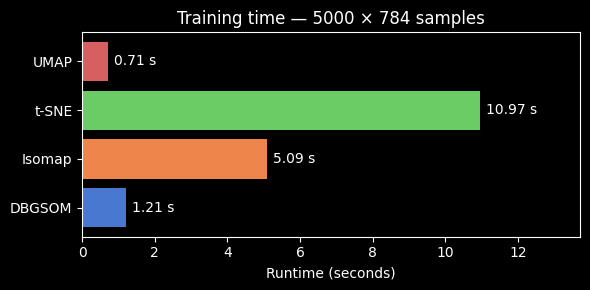

In [22]:
fig, ax = plt.subplots(figsize=(6, 3))
names = list(runtimes.keys())
times = list(runtimes.values())
bars = ax.barh(names, times, color=sns.color_palette("muted", len(names)))
ax.bar_label(bars, fmt="%.2f s", padding=4)
ax.set_xlabel("Runtime (seconds)")
ax.set_title(f"Training time — {X.shape[0]} × {X.shape[1]} samples")
ax.set_xlim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()